In [35]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("student_data.csv")

In [3]:
data

,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
0,1,Amit,Male,20.0,Computer,78.0,85.0,Pune
1,2,Priya,Female,21.0,IT,88.0,90.0,Mumbai
2,3,Rahul,Male,19.0,Mechanical,67.0,75.0,Nashik
3,4,Sneha,Female,22.0,Computer,92.0,95.0,Pune
4,5,Akash,Male,20.0,Civil,55.0,60.0,Aurangabad
5,6,Neha,Female,21.0,IT,73.0,80.0,Mumbai
6,7,Rohan,Male,23.0,Mechanical,49.0,65.0,Nagpur
7,8,Kajal,Female,20.0,Computer,81.0,88.0,Pune
8,9,Arjun,Male,22.0,Civil,60.0,70.0,Nashik
9,10,Pooja,Female,19.0,IT,77.0,85.0,Mumbai


In [5]:
data.isnull()

,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

StudentID     0
Name          0
Gender        0
Age           1
Department    1
Marks         1
Attendance    1
City          1
dtype: int64

In [8]:
null_col = ["Age", "Marks", "Attendance"]

for col in null_col:
    data[col] = data[col].fillna(data[col].mean())

In [12]:
data.isnull().sum()

StudentID     0
Name          0
Gender        0
Age           0
Department    1
Marks         0
Attendance    0
City          1
dtype: int64

In [13]:
data


,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
0,1,Amit,Male,20.000000,Computer,78.000000,85.000000,Pune
1,2,Priya,Female,21.000000,IT,88.000000,90.000000,Mumbai
2,3,Rahul,Male,19.000000,Mechanical,67.000000,75.000000,Nashik
3,4,Sneha,Female,22.000000,Computer,92.000000,95.000000,Pune
4,5,Akash,Male,20.000000,Civil,55.000000,60.000000,Aurangabad
5,6,Neha,Female,21.000000,IT,73.000000,80.000000,Mumbai
6,7,Rohan,Male,23.000000,Mechanical,49.000000,65.000000,Nagpur
7,8,Kajal,Female,20.000000,Computer,81.000000,88.000000,Pune
8,9,Arjun,Male,22.000000,Civil,60.000000,70.000000,Nashik
9,10,Pooja,Female,19.000000,IT,77.000000,85.000000,Mumbai


<Axes: >

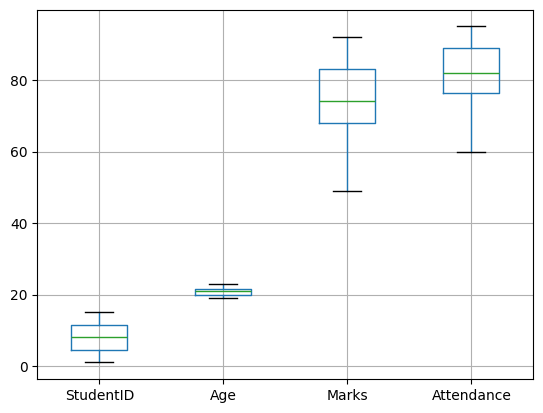

In [14]:
data.boxplot()

In [19]:
newdata = data[data["Marks"] > 80]
newdata

,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
1,2,Priya,Female,21.000000,IT,88.0,90.0,Mumbai
3,4,Sneha,Female,22.000000,Computer,92.0,95.0,Pune
7,8,Kajal,Female,20.000000,Computer,81.0,88.0,Pune
10,11,Vikas,Male,20.785714,Computer,85.0,90.0,Pune
11,12,Anjali,Female,21.000000,NaN,91.0,92.0,Nagpur


In [22]:
newdata.boxplot()

<Axes: >

In [25]:
Q1 = data[null_col].quantile(0.25)
Q3 = data[null_col].quantile(0.75)
IQR = Q3 - Q1

outliers = ((data[null_col] < (Q1 - 1.5 * IQR)) |
             (data[null_col] > (Q1 + 1.5 * IQR)))

print(outliers)

      Age  Marks  Attendance
0   False  False       False
1   False  False       False
2   False  False       False
3   False   True       False
4   False  False       False
5   False  False       False
6    True  False       False
7   False  False       False
8   False  False       False
9   False  False       False
10  False  False       False
11  False   True       False
12  False  False       False
13  False  False       False
14  False  False       False


In [28]:
Q1 = data[null_col].quantile(0.25)
Q3 = data[null_col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data[null_col] = data[null_col].clip(lower, upper, axis=1)

In [29]:
outliers = ((data[null_col] < lower) | (data[null_col] > upper))
print(outliers)

      Age  Marks  Attendance
0   False  False       False
1   False  False       False
2   False  False       False
3   False  False       False
4   False  False       False
5   False  False       False
6   False  False       False
7   False  False       False
8   False  False       False
9   False  False       False
10  False  False       False
11  False  False       False
12  False  False       False
13  False  False       False
14  False  False       False


In [31]:
data

,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
0,1,Amit,Male,20.000000,Computer,78.000000,85.000000,Pune
1,2,Priya,Female,21.000000,IT,88.000000,90.000000,Mumbai
2,3,Rahul,Male,19.000000,Mechanical,67.000000,75.000000,Nashik
3,4,Sneha,Female,22.000000,Computer,92.000000,95.000000,Pune
4,5,Akash,Male,20.000000,Civil,55.000000,60.000000,Aurangabad
5,6,Neha,Female,21.000000,IT,73.000000,80.000000,Mumbai
6,7,Rohan,Male,23.000000,Mechanical,49.000000,65.000000,Nagpur
7,8,Kajal,Female,20.000000,Computer,81.000000,88.000000,Pune
8,9,Arjun,Male,22.000000,Civil,60.000000,70.000000,Nashik
9,10,Pooja,Female,19.000000,IT,77.000000,85.000000,Mumbai


In [32]:
data.boxplot()

<Axes: >

In [36]:
print(data["Age"].skew())

0.1613134966718857


In [37]:
data["Age"] = ((data["Age"] - data["Age"].min()) / (data["Age"].max() - data["Age"].min()))

In [39]:
print(data.head())

   StudentID   Name  Gender       Age  Department  Marks  Attendance  \
0          1   Amit    Male -1.386294    Computer   78.0        85.0   
1          2  Priya  Female -0.693147          IT   88.0        90.0   
2          3  Rahul    Male      -inf  Mechanical   67.0        75.0   
3          4  Sneha  Female -0.287682    Computer   92.0        95.0   
4          5  Akash    Male -1.386294       Civil   55.0        60.0   

         City  
0        Pune  
1      Mumbai  
2      Nashik  
3        Pune  
4  Aurangabad  


In [40]:
data


,StudentID,Name,Gender,Age,Department,Marks,Attendance,City
0,1,Amit,Male,-1.386294,Computer,78.000000,85.000000,Pune
1,2,Priya,Female,-0.693147,IT,88.000000,90.000000,Mumbai
2,3,Rahul,Male,-inf,Mechanical,67.000000,75.000000,Nashik
3,4,Sneha,Female,-0.287682,Computer,92.000000,95.000000,Pune
4,5,Akash,Male,-1.386294,Civil,55.000000,60.000000,Aurangabad
5,6,Neha,Female,-0.693147,IT,73.000000,80.000000,Mumbai
6,7,Rohan,Male,0.000000,Mechanical,49.000000,65.000000,Nagpur
7,8,Kajal,Female,-1.386294,Computer,81.000000,88.000000,Pune
8,9,Arjun,Male,-0.287682,Civil,60.000000,70.000000,Nashik
9,10,Pooja,Female,-inf,IT,77.000000,85.000000,Mumbai
